ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](img/step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("Customer_support_data.csv")
df.head(10)

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5
5,1cfde5b9-6112-44fc-8f3b-892196137a62,Email,Returns,Fraudulent User,NaN,a2938961-2833-45f1-83d6-678d9555c603,NaN,01/08/2023 15:13,01/08/2023 18:39,01-Aug-23,NaN,NaN,NaN,NaN,Desiree Newton,Emma Park,John Smith,0-30,Morning,5
6,11a3ffd8-1d6b-4806-b198-c60b5934c9bc,Outcall,Product Queries,Product Specific Information,NaN,bfcb562b-9a2f-4cca-aa79-fd4e2952f901,NaN,01/08/2023 15:31,01/08/2023 23:52,01-Aug-23,NaN,NaN,NaN,NaN,Shannon Hicks,Aiden Patel,Olivia Tan,>90,Morning,5
7,372b51a5-fa19-4a31-a4b8-a21de117d75e,Inbound,Returns,Exchange / Replacement,Very good,88537e0b-5ffa-43f9-bbe2-fe57a0f4e4ae,NaN,01/08/2023 16:17,01/08/2023 16:23,01-Aug-23,NaN,NaN,NaN,NaN,Laura Smith,Evelyn Kimura,Jennifer Nguyen,On Job Training,Evening,5
8,6e4413db-4e16-42fc-ac92-2f402e3df03c,Inbound,Returns,Missing,Shopzilla app and it's all coustomer care serv...,e6be9713-13c3-493c-8a91-2137cbbfa7e6,NaN,01/08/2023 21:03,01/08/2023 21:07,01-Aug-23,NaN,NaN,NaN,NaN,David Smith,Nathan Patel,John Smith,>90,Split,5
9,b0a65350-64a5-4603-8b9a-a24a4a145d08,Inbound,Shopzilla Related,General Enquiry,NaN,c7caa804-2525-499e-b202-4c781cb68974,NaN,01/08/2023 23:31,01/08/2023 23:36,01-Aug-23,NaN,NaN,NaN,NaN,Tabitha Ayala,Amelia Tanaka,Michael Lee,31-60,Evening,5


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Date` should be datetime
- `Revenue` should be numeric

In [3]:
df.dtypes

Unique id                   object
channel_name                object
category                    object
Sub-category                object
Customer Remarks            object
Order_id                    object
order_date_time             object
Issue_reported at           object
issue_responded             object
Survey_response_Date        object
Customer_City               object
Product_category            object
Item_price                 float64
connected_handling_time    float64
Agent_name                  object
Supervisor                  object
Manager                     object
Tenure Bucket               object
Agent Shift                 object
CSAT Score                   int64
dtype: object

In [4]:
df.info()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

0

The dataset contains several missing values in multiple columns, especially connected_handling_time, Customer_City, Product_category, and Item_price, order_date_time, Order_id, Cutomer Remarks.

No duplicate rows were found in the dataset.

### 2.2 Convert Incorrect Data Types


In [25]:
# convert date columns to datetime format
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], dayfirst=True, errors='coerce')

df['issue_responded'] = pd.to_datetime(df['issue_responded'], dayfirst=True, errors='coerce', infer_datetime_format=True)

df['Survey_response_Date'] = pd.to_datetime(df['Survey_response_Date'], dayfirst=True, errors='coerce', infer_datetime_format=True)

C:\Users\Huawei\AppData\Local\Temp\ipykernel_19220\1261230260.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['issue_responded'] = pd.to_datetime(df['issue_responded'], dayfirst=True, errors='coerce', infer_datetime_format=True)
C:\Users\Huawei\AppData\Local\Temp\ipykernel_19220\1261230260.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Survey_response_Date'] = pd.to_datetime(df['Survey_response_Date'], dayfirst=True, errors='coerce', infer_datetime_format=True)


In [26]:
df.dtypes

Unique id                          object
channel_name                       object
category                           object
Sub-category                       object
Customer Remarks                   object
Order_id                           object
order_date_time                    object
Issue_reported at          datetime64[ns]
issue_responded            datetime64[ns]
Survey_response_Date       datetime64[ns]
Customer_City                      object
Product_category                   object
Item_price                        float64
connected_handling_time           float64
Agent_name                         object
Supervisor                         object
Manager                            object
Tenure Bucket                      object
Agent Shift                        object
CSAT Score                          int64
Item_price_MinMax                 float64
Item_price_Zscore                 float64
dtype: object

The date columns were converted from object type to datetime format to support time-based analysis.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [7]:
# create artificial missing values in the 'Item_price' column for demonstration purposes
df.loc[0:5, 'Item_price'] = np.nan

In [8]:
df['Item_price'].isnull().sum()

68701

In [9]:
# median imputation
median_value = df['Item_price'].median()

df['Item_price'] = df['Item_price'].fillna(median_value)

In [10]:
df['Item_price'].isnull().sum()

0

Median imputation was applied because it is robust to outliers and preserves all records in the dataset.

In [11]:
print("Original shape: ",df.shape)
df_missing = df.copy()
df_missing.loc[0:10, 'item_price'] = np.nan
print("After creating missing values: ",df_missing.shape)

Original shape:  (85907, 20)
After creating missing values:  (85907, 21)


## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.

![IQR.png](img/IQR.png)

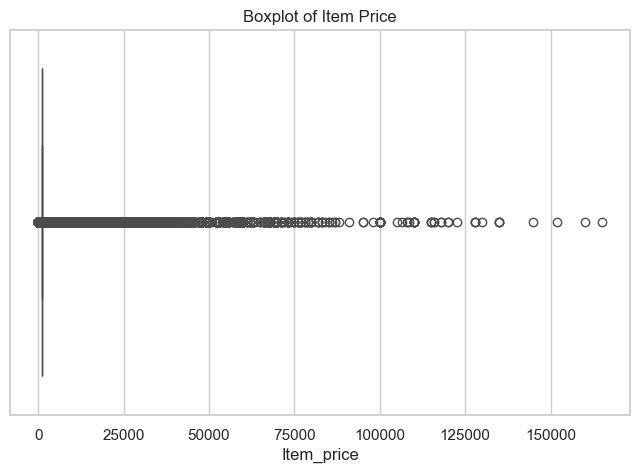

In [27]:
# use (item_price) - boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Item_price'])
plt.title('Boxplot of Item Price')
plt.show()

In [14]:
# calculate IQR
Q1 = df['Item_price'].quantile(0.25)

Q3 = df['Item_price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

In [15]:
# detect outliers
outliers = df[
    (df['Item_price'] < lower_bound) |
    (df['Item_price'] > upper_bound)
]

outliers

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
11,4c28acf4-2ea4-4be8-b8f1-113e676fc8b7,Inbound,Order Related,Delayed,Very bad,55bbace3-eb2e-4f67-aacb-4f8ee8512f75,19/07/2023 23:50,2023-08-02 10:44:00,2023-08-02 11:14:00,2023-08-02,NAGPUR,LifeStyle,434.0,NaN,Stanley Hogan,Harper Wong,Emily Chen,>90,Split,1
16,4cc4df74-fcd3-413a-920d-ca3ad2dd0904,Inbound,Returns,Service Centres Related,NaN,4245d6df-49c6-491a-8724-125c4df82e75,06/05/2023 21:41,2023-08-01 09:01:00,2023-08-01 09:03:00,2023-08-01,RANCHI,Electronics,1299.0,NaN,Amy Mendez,Sophia Sato,John Smith,0-30,Morning,5
19,6e51734e-9627-4a12-8062-877c3638627d,Inbound,Order Related,Installation/demo,All good,8a1ae638-4d8c-4a5e-bf1b-eb74f881fc3d,18/07/2023 12:20,2023-08-02 20:03:00,2023-08-02 20:05:00,2023-08-02,NAGPUR,Electronics,15990.0,NaN,David Butler,Olivia Wang,Emily Chen,31-60,Evening,5
24,081f62d7-332f-4aac-91cf-e79758976725,Inbound,Returns,Reverse Pickup Enquiry,NaN,2509fa08-318d-4526-8122-51603af956a8,15/07/2023 14:47,2023-08-01 08:55:00,2023-08-01 08:57:00,2023-08-01,BETIA,Electronics,1099.0,NaN,Cynthia Mills,William Park,John Smith,31-60,Morning,5
25,c0edcb0a-cfa8-4f35-86ad-88c9f6b47290,Inbound,Order Related,Order status enquiry,Issue not resolved pathetic service,e4eed4bb-1b1e-4894-bbd0-e2ba491b562b,29/07/2023 13:35,2023-08-02 11:07:00,2023-08-02 11:10:00,2023-08-02,NEW DELHI,Mobile,99999.0,NaN,Michelle Williams,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85878,712c3a65-c180-4ebb-8c0e-70f7f533b0e0,Inbound,Feedback,UnProfessional Behaviour,NaN,3988923a-3c7e-42d5-9869-3aa089c7ca99,20/08/2023 19:50,2023-08-31 11:04:00,2023-08-31 11:25:00,2023-08-31,Singrauli,Books & General merchandise,25.0,NaN,Jennifer Lewis,Madison Kim,John Smith,>90,Morning,5
85881,c3d87534-42e5-41b1-8b37-632d2b3db1a8,Inbound,Order Related,Order status enquiry,Clear all my problem thanks for Shopzilla,ced3b2fd-6833-44c7-bab3-d956fbea7015,28/08/2023 19:49,2023-08-31 12:37:00,2023-08-31 12:38:00,2023-08-31,PUNE,Electronics,599.0,NaN,Ashley Dunlap,Aiden Patel,Olivia Tan,On Job Training,Evening,5
85886,f3e04cee-efae-42be-9c4d-8ef929261760,Inbound,Returns,Wrong,NaN,77d27b17-7523-4369-adcd-8a4463694737,14/08/2023 23:11,2023-08-31 10:56:00,2023-08-31 11:02:00,2023-08-31,GUWAHATI,Home Appliences,998.0,NaN,Amanda Benjamin,Amelia Tanaka,Emily Chen,>90,Morning,4
85900,9ecbd0e0-dff3-475d-aca2-297144229e9c,Inbound,Order Related,Delayed,NaN,1b033755-0b17-4f3b-901c-f173c03c95e2,14/08/2023 18:43,2023-08-31 11:42:00,2023-08-31 11:45:00,2023-08-31,BHUPALAPALLI,Books & General merchandise,193.0,NaN,Diana White,Layla Taniguchi,Emily Chen,>90,Morning,5


In [28]:
# number of outliers
len(outliers)

17199

In [29]:
# remove outliers
df_clean = df[
    (df['Item_price'] >= lower_bound) &
    (df['Item_price'] <= upper_bound)
]

The IQR method was used to detect extreme values. Records outside the acceptable range were removed to reduce the impact of outliers.

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization

In [17]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

df['Item_price_MinMax'] = minmax.fit_transform(
    df[['Item_price']]
)

df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Item_price_MinMax
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,NaN,NaN,979.0,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0.005933
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,NaN,NaN,979.0,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0.005933
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,NaN,NaN,979.0,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,0.005933
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,NaN,NaN,979.0,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,0.005933
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,NaN,NaN,979.0,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,0.005933


### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:

![zscore.png](img/zscore.png)

This method keeps the shape of the distribution but rescales it around zero.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Item_price_Zscore'] = scaler.fit_transform(
    df[['Item_price']]
)

df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Item_price_MinMax,Item_price_Zscore
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,NaN,NaN,979.0,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0.005933,-0.155302
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,NaN,NaN,979.0,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0.005933,-0.155302
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,NaN,NaN,979.0,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,0.005933,-0.155302
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,NaN,NaN,979.0,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,0.005933,-0.155302
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,NaN,NaN,979.0,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,0.005933,-0.155302


Min-Max normalization scales values between 0 and 1, while Z-score normalization standardizes the data around a mean of 0 and a standard deviation of 1.

## Task 5 - PCA

In [30]:
# select numerical features 
features = df[
    ['Item_price',
     'connected_handling_time',
     'CSAT Score']
]

In [31]:
features = features.fillna(features.median()) 

In [32]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [33]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(
    scaled_features
)

In [35]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.3637124  0.33337748]


In [36]:
# PCA DataFrame
pca_df = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2']
)

pca_df.head()

,PC1,PC2
0,0.498379,-0.002622
1,0.498379,-0.002622
2,0.498379,-0.002622
3,0.498379,-0.002622
4,0.498379,-0.002622


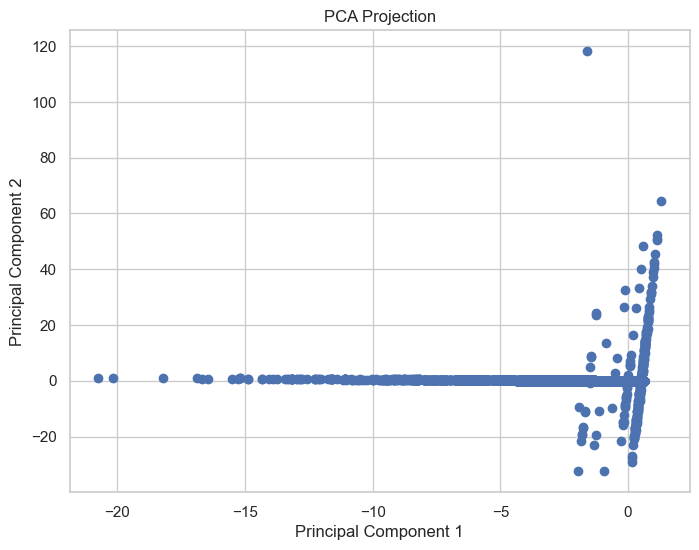

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2']
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection')
plt.show()

PCA was applied to reduce dimensionality while retaining most of the information in the dataset. The explained variance ratio indicates how much variance is captured by each principal component.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of Assignment 2